# Clipping de segmentos de reta — C‑S, L‑B, N‑L‑N

Window normalizada $[-1,1]\times[-1,1]$, $WC=(0,0)$:
$x_{min}=y_{min}=-1$, $x_{max}=y_{max}=1$. Pontos em NDC; vírgula = decimal.

Segmentos (Fig. 1):

| Seg | $P_0$ | $P_1$ |
|:--:|:--:|:--:|
| A | $(-4{,}0;\ 0{,}5)$ | $(-0{,}1;\ 2{,}5)$ |
| B | $(-0{,}5;\ 0{,}0)$ | $(0{,}9;\ 0{,}4)$ |
| C | $(-0{,}5;\ 0{,}0)$ | $(1{,}0;\ 0{,}5)$ |
| D | $(0{,}4;\ -0{,}2)$ | $(2{,}8;\ 1{,}5)$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
XMIN, YMIN, XMAX, YMAX = -1.0, -1.0, 1.0, 1.0


In [2]:
# Cohen-Sutherland
INSIDE, LEFT, RIGHT, BOTTOM, TOP = 0, 1, 2, 4, 8
def outcode(x, y):
    c = INSIDE
    if x < XMIN: c |= LEFT
    elif x > XMAX: c |= RIGHT
    if y < YMIN: c |= BOTTOM
    elif y > YMAX: c |= TOP
    return c
def cohen_sutherland(p0, p1):
    x0, y0 = p0; x1, y1 = p1
    c0, c1 = outcode(x0, y0), outcode(x1, y1)
    while True:
        if not (c0 | c1): return (x0, y0), (x1, y1)
        if c0 & c1: return None
        c = c0 or c1
        if c & TOP:      x = x0+(x1-x0)*(YMAX-y0)/(y1-y0); y = YMAX
        elif c & BOTTOM: x = x0+(x1-x0)*(YMIN-y0)/(y1-y0); y = YMIN
        elif c & RIGHT:  y = y0+(y1-y0)*(XMAX-x0)/(x1-x0); x = XMAX
        else:            y = y0+(y1-y0)*(XMIN-x0)/(x1-x0); x = XMIN
        if c == c0: x0, y0 = x, y; c0 = outcode(x0, y0)
        else:       x1, y1 = x, y; c1 = outcode(x1, y1)

# Liang-Barsky
def liang_barsky(p0, p1):
    x0, y0 = p0; x1, y1 = p1
    dx, dy = x1-x0, y1-y0
    p = (-dx, dx, -dy, dy)
    q = (x0-XMIN, XMAX-x0, y0-YMIN, YMAX-y0)
    t0, t1 = 0.0, 1.0
    for pk, qk in zip(p, q):
        if pk == 0:
            if qk < 0: return None
            continue
        t = qk/pk
        if pk < 0:
            if t > t1: return None
            t0 = max(t0, t)
        else:
            if t < t0: return None
            t1 = min(t1, t)
    return (x0+t0*dx, y0+t0*dy), (x0+t1*dx, y0+t1*dy)

# Sutherland-Hodgman (polígono, Parte 3)
def sh_x(a, b, bnd, axis):
    ax, ay = a; bx, by = b
    if axis == "x":
        t = (bnd-ax)/(bx-ax); return (bnd, ay+t*(by-ay))
    t = (bnd-ay)/(by-ay); return (ax+t*(bx-ax), bnd)
def sutherland_hodgman(poly):
    edges = [(lambda x,y: x>=XMIN, XMIN, "x"), (lambda x,y: x<=XMAX, XMAX, "x"),
             (lambda x,y: y>=YMIN, YMIN, "y"), (lambda x,y: y<=YMAX, YMAX, "y")]
    out = list(poly)
    for inside, bnd, axis in edges:
        if not out: break
        src, out = out, []
        prev = src[-1]; pin = inside(*prev)
        for cur in src:
            cin = inside(*cur)
            if cin:
                if not pin: out.append(sh_x(prev, cur, bnd, axis))
                out.append(cur)
            elif pin: out.append(sh_x(prev, cur, bnd, axis))
            prev, pin = cur, cin
    return out


In [3]:
def draw_window(ax):
    ax.add_patch(plt.Rectangle((XMIN,YMIN), 2, 2, fill=True, fc="0.92",
                               ec="steelblue", lw=1.5, zorder=0))
def plot_segment(name, p0, p1, clip):
    fig, ax = plt.subplots(figsize=(4.2, 4.2)); draw_window(ax)
    ax.plot([p0[0],p1[0]],[p0[1],p1[1]], "--", color="0.6")
    ax.scatter(*zip(p0,p1), color="0.6")
    if clip is None: ax.set_title(f"{name}: rejeitado")
    else:
        a,b = clip; ax.plot([a[0],b[0]],[a[1],b[1]], "-", color="crimson", lw=2.5)
        ax.scatter(*zip(a,b), color="crimson"); ax.set_title(name)
    ax.set_xlim(-4.4,4.4); ax.set_ylim(-2.4,3.4); ax.set_aspect("equal")
    plt.tight_layout(); plt.show()
def plot_polygon(name, poly, clip):
    fig, ax = plt.subplots(figsize=(4.6,4.6)); draw_window(ax)
    px=[p[0] for p in poly]+[poly[0][0]]; py=[p[1] for p in poly]+[poly[0][1]]
    ax.plot(px, py, "--", color="0.55")
    if clip:
        cx=[p[0] for p in clip]+[clip[0][0]]; cy=[p[1] for p in clip]+[clip[0][1]]
        ax.fill(cx, cy, color="crimson", alpha=.25); ax.plot(cx, cy, "-", color="crimson", lw=2)
    ax.set_title(name); ax.set_xlim(-2.4,2.6); ax.set_ylim(-2.0,3.2)
    ax.set_aspect("equal"); plt.tight_layout(); plt.show()


## A — $(-4{,}0;\ 0{,}5) \to (-0{,}1;\ 2{,}5)$

**C‑S.** Outcodes (`TOP BOTTOM RIGHT LEFT`): $P_0 = 0001$ ($x<-1$), $P_1 = 1000$ ($y>1$).
$c_0\land c_1 = 0$ → não rejeita direto. **Heurística:** trato $P_0$ (fora, LEFT), corto em $x=-1$:
$$y = 0{,}5 + (2{,}5-0{,}5)\tfrac{-1+4}{-0{,}1+4} = 0{,}5 + 2\cdot\tfrac{3}{3{,}9} = 2{,}0385.$$
Novo $P_0=(-1;\,2{,}0385)$ → outcode $1000$. Agora $c_0\land c_1 = 1000 \ne 0$ → **rejeita**.

**L‑B.** $dx=3{,}9,\ dy=2{,}0$; $p=(-3{,}9;\,3{,}9;\,-2{,}0;\,2{,}0)$, $q=(-3;\,5;\,1{,}5;\,0{,}5)$.

| borda | $t=q/p$ | tipo | $t_0,t_1$ |
|:--|:--:|:--|:--|
| ESQ | $0{,}7692$ | entra | $t_0=0{,}7692$ |
| DIR | $1{,}2821$ | sai | $t_1=1$ |
| BAIXO | $-0{,}75$ | entra | $t_0=0{,}7692$ |
| TOPO | $0{,}25$ | sai | $t_1=0{,}25$ |

$t_1=0{,}25 < t_0=0{,}7692$ → **rejeita**.

**N‑L‑N.** $P_0$ fora à esquerda; comparo contra os raios aos **cantos esquerdos**:
$m_{P_0\to(-1,1)}=\tfrac{0{,}5}{3}=0{,}1667$, $m_{P_0\to(-1,-1)}=\tfrac{-1{,}5}{3}=-0{,}5$.
Segmento: $m=\tfrac{2{,}0}{3{,}9}=0{,}5128$. Como $0{,}5128 > 0{,}1667$, passa acima do canto sup‑esq → **rejeita**.


A · CS: None | LB: None


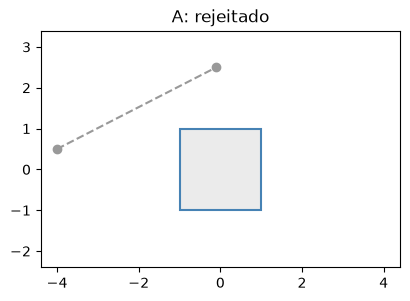

In [4]:
pA0, pA1 = (-4.0, 0.5), (-0.1, 2.5)
print("A · CS:", cohen_sutherland(pA0, pA1), "| LB:", liang_barsky(pA0, pA1))
plot_segment("A", pA0, pA1, cohen_sutherland(pA0, pA1))


## B — $(-0{,}5;\ 0{,}0) \to (0{,}9;\ 0{,}4)$

Os dois extremos estão dentro ($-1\le x,y\le 1$).

**C‑S.** $c_0 = c_1 = 0000$, $c_0\lor c_1 = 0$ → **aceita inteiro**.

**L‑B.** $q=(0{,}5;\,1{,}5;\,1{,}0;\,0{,}6)$ (todos $>0$) → $t_0=0,\ t_1=1$ → **inteiro**.

**N‑L‑N.** $P_0$ dentro; $P_1$ também dentro (não cruza raio de canto) → **inteiro**.

Resultado: $(-0{,}5;\,0) \to (0{,}9;\,0{,}4)$.


B · CS: ((-0.5, 0.0), (0.9, 0.4)) | LB: ((-0.5, 0.0), (0.8999999999999999, 0.4))


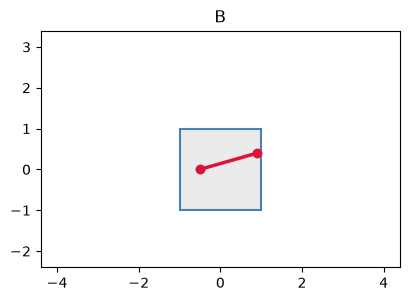

In [5]:
pB0, pB1 = (-0.5, 0.0), (0.9, 0.4)
print("B · CS:", cohen_sutherland(pB0, pB1), "| LB:", liang_barsky(pB0, pB1))
plot_segment("B", pB0, pB1, cohen_sutherland(pB0, pB1))


## C — $(-0{,}5;\ 0{,}0) \to (1{,}0;\ 0{,}5)$

$P_1$ tem $x=1{,}0$: na borda conta como dentro ($x\le 1$).

**C‑S.** $c_0 = c_1 = 0000$ → **aceita inteiro**.

**L‑B.** borda DIR: $t=q/p=1{,}5/1{,}5=1$ (sai no próprio $P_1$); $t_0=0,\ t_1=1$ → **inteiro**.

**N‑L‑N.** $P_0$ e $P_1$ dentro → **inteiro**.

Resultado: $(-0{,}5;\,0) \to (1{,}0;\,0{,}5)$.


C · CS: ((-0.5, 0.0), (1.0, 0.5)) | LB: ((-0.5, 0.0), (1.0, 0.5))


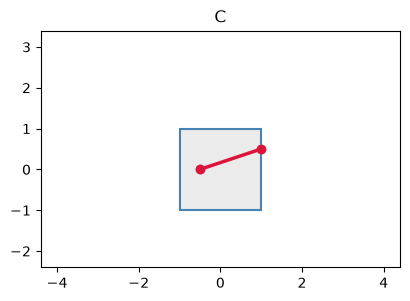

In [6]:
pC0, pC1 = (-0.5, 0.0), (1.0, 0.5)
print("C · CS:", cohen_sutherland(pC0, pC1), "| LB:", liang_barsky(pC0, pC1))
plot_segment("C", pC0, pC1, cohen_sutherland(pC0, pC1))


## D — $(0{,}4;\ -0{,}2) \to (2{,}8;\ 1{,}5)$

$P_0$ dentro, $P_1$ fora (canto sup‑dir: $x>1$ e $y>1$).

**C‑S.** $c_0=0000$, $c_1=1010$ (TOP+RIGHT). **Heurística:** trato $P_1$, bit TOP primeiro, corto em $y=1$:
$$x = 0{,}4 + 2{,}4\cdot\tfrac{1+0{,}2}{1{,}5+0{,}2} = 0{,}4 + 2{,}4\cdot\tfrac{1{,}2}{1{,}7} = 2{,}0941.$$
$P_1=(2{,}0941;\,1)$ → outcode $0010$ (RIGHT). Corto em $x=1$ (segmento atual):
$$y = -0{,}2 + 1{,}2\cdot\tfrac{1-0{,}4}{2{,}0941-0{,}4} = -0{,}2 + 0{,}4250 = 0{,}2250.$$
$P_1=(1;\,0{,}2250)$ → dentro → **aceita**. Resultado: $(0{,}4;\,-0{,}2)\to(1{,}0;\,0{,}2250)$.

**L‑B.** $dx=2{,}4,\ dy=1{,}7$; $p=(-2{,}4;\,2{,}4;\,-1{,}7;\,1{,}7)$, $q=(1{,}4;\,0{,}6;\,0{,}8;\,1{,}2)$.

| borda | $t=q/p$ | tipo | $t_0,t_1$ |
|:--|:--:|:--|:--|
| ESQ | $-0{,}5833$ | entra | $t_0=0$ |
| DIR | $0{,}25$ | sai | $t_1=0{,}25$ |
| BAIXO | $-0{,}4706$ | entra | $t_0=0$ |
| TOPO | $0{,}7059$ | sai | $t_1=0{,}25$ |

$t_0=0,\ t_1=0{,}25$. $P_{end}=(0{,}4+0{,}25\cdot2{,}4;\ -0{,}2+0{,}25\cdot1{,}7)=(1{,}0;\ 0{,}2250)$.

**N‑L‑N.** $P_0$ dentro. Raios aos cantos: $m_{TR}=2{,}0$, $m_{BR}=-1{,}3333$, $m_{TL}=-0{,}8571$, $m_{BL}=0{,}5714$.
Segmento: $\Delta x=2{,}4>0$ (vai p/ direita), $m=1{,}7/2{,}4=0{,}7083$. **Heurística:** $\Delta x>0$ → comparo só com os raios direitos (BR, TR):
$-1{,}3333 \le 0{,}7083 \le 2{,}0$ → sai pela **borda direita** $x=1$:
$$y = -0{,}2 + 0{,}7083\cdot(1-0{,}4) = 0{,}2250.$$
Resultado: $(0{,}4;\,-0{,}2)\to(1{,}0;\,0{,}2250)$.


D · CS: ((0.4, -0.2), (1.0, 0.22499999999999992)) | LB: ((0.4, -0.2), (1.0, 0.22499999999999998))


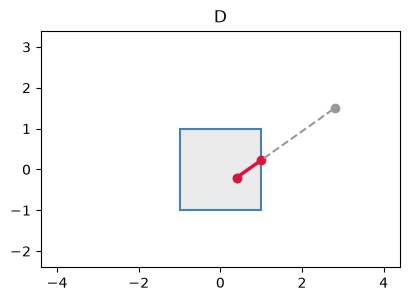

In [7]:
pD0, pD1 = (0.4, -0.2), (2.8, 1.5)
print("D · CS:", cohen_sutherland(pD0, pD1), "| LB:", liang_barsky(pD0, pD1))
plot_segment("D", pD0, pD1, cohen_sutherland(pD0, pD1))


## Pergunta (N‑L‑N)

**Qual a mais simples heurística para escolher contra quais retas de referência comparar o coeficiente angular?**

O **sinal de $\Delta x$ e $\Delta y$** (do vetor $P_1-P_0$). Ele diz o quadrante para onde o segmento aponta, e cada quadrante encosta em **2** dos raios aos cantos — comparo só contra esses dois.

- $\Delta x>0$ → raios direitos (TR, BR); $\Delta x<0$ → esquerdos (TL, BL). Idem $\Delta y$ para cima/baixo.

**Justificativa:** um segmento só pode sair pela borda do lado para onde aponta, então os 2 raios do lado oposto são inúteis. O sinal é um teste $O(1)$ que descarta metade dos raios — sobram 2 comparações de inclinação (é isso que torna o N‑L‑N mais barato que testar as 4 bordas).


## Polígonos (Fig. 2) — Sutherland‑Hodgman

C‑S/L‑B/N‑L‑N recortam segmentos; polígono usa **Sutherland‑Hodgman**: recorto contra uma borda por vez, ordem **ESQ → DIR → BAIXO → TOPO**; a saída de uma passada entra na próxima. Regra por aresta $P_{prev}\to P_{cur}$: dentro→dentro guarda $P_{cur}$; dentro→fora guarda a interseção; fora→dentro guarda interseção e $P_{cur}$; fora→fora nada.


### Estrela

Vértices (ordem do contorno): $V_1(-0{,}8;2{,}8)$, $V_2(-0{,}9;1{,}1)$, $V_3(-1{,}8;0{,}8)$, $V_4(-0{,}9;0{,}6)$, $V_5(-0{,}8;-1{,}2)$, $V_6(-0{,}5;0{,}6)$, $V_7(0{,}2;0{,}8)$, $V_8(-0{,}5;1{,}1)$.

**ESQ ($x\ge-1$).** Fora: $V_3$. Interseções em $x=-1$:
$V_2\to V_3$: $y=1{,}1+(0{,}8-1{,}1)\tfrac{-1+0{,}9}{-1{,}8+0{,}9}=1{,}0667$;
$V_3\to V_4$: $y=0{,}8+(0{,}6-0{,}8)\tfrac{-1+1{,}8}{-0{,}9+1{,}8}=0{,}6222$.
$V_3 \to (-1;1{,}0667),(-1;0{,}6222)$.

**DIR ($x\le1$).** Maior $x$ é $0{,}2$ → nada muda.

**BAIXO ($y\ge-1$).** Fora: $V_5$. Interseções em $y=-1$:
$V_4\to V_5$: $x=-0{,}9+(-0{,}8+0{,}9)\tfrac{-1-0{,}6}{-1{,}2-0{,}6}=-0{,}8111$;
$V_5\to V_6$: $x=-0{,}8+(-0{,}5+0{,}8)\tfrac{-1+1{,}2}{0{,}6+1{,}2}=-0{,}7667$.

**TOPO ($y\le1$).** Fora (y>1) e seguidos: $V_8,V_1,V_2,(-1;1{,}0667)$. Dois cruzamentos:
$(-1;1{,}0667)\to(-1;0{,}6222)$ em $x=-1$ → $(-1;1)$;
$V_7\to V_8$: $x=0{,}2+(-0{,}5-0{,}2)\tfrac{1-0{,}8}{1{,}1-0{,}8}=-0{,}2667$ → $(-0{,}2667;1)$.


Estrela — 8 vértices:
  (-1.0000, +1.0000)
  (-1.0000, +0.6222)
  (-0.9000, +0.6000)
  (-0.8111, -1.0000)
  (-0.7667, -1.0000)
  (-0.5000, +0.6000)
  (+0.2000, +0.8000)
  (-0.2667, +1.0000)


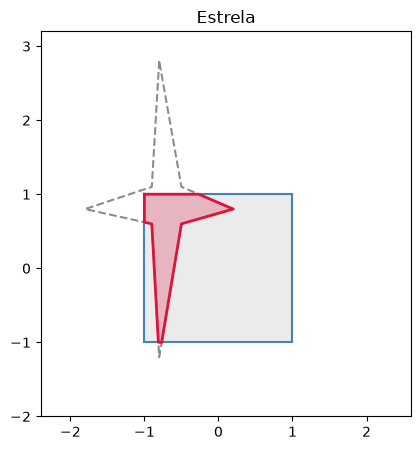

In [8]:
star = [(-0.8,2.8),(-0.9,1.1),(-1.8,0.8),(-0.9,0.6),(-0.8,-1.2),(-0.5,0.6),(0.2,0.8),(-0.5,1.1)]
star_clip = sutherland_hodgman(star)
print(f"Estrela — {len(star_clip)} vértices:")
for i,(x,y) in enumerate(star_clip,1): print(f"  ({x:+.4f}, {y:+.4f})")
plot_polygon("Estrela", star, star_clip)


### Seta

Vértices: $U_1(0{,}5;0)$, $U_2(2{,}0;-0{,}5)$, $U_3(1{,}2;-1{,}4)$, $U_4(0{,}5;-0{,}9)$, $U_5(-0{,}5;1{,}1)$.

**ESQ ($x\ge-1$).** Todos $x\ge-0{,}5$ → nada muda.

**DIR ($x\le1$).** Fora: $U_2,U_3$. Interseções em $x=1$:
$U_1\to U_2$: $y=0+(-0{,}5)\tfrac{1-0{,}5}{2-0{,}5}=-0{,}1667$;
$U_3\to U_4$: $y=-1{,}4+(-0{,}9+1{,}4)\tfrac{1-1{,}2}{0{,}5-1{,}2}=-1{,}2571$.

**BAIXO ($y\ge-1$).** Fora: $(1;-1{,}2571)$. Interseções em $y=-1$:
na reta $x=1$ → $(1;-1)$; para $U_4$: $x=1+(0{,}5-1)\tfrac{-1+1{,}2571}{-0{,}9+1{,}2571}=0{,}6400$ → $(0{,}64;-1)$.

**TOPO ($y\le1$).** Fora: $U_5$. Interseções em $y=1$:
$U_4\to U_5$: $x=0{,}5+(-0{,}5-0{,}5)\tfrac{1+0{,}9}{1{,}1+0{,}9}=-0{,}45$ → $(-0{,}45;1)$;
$U_5\to U_1$: $x=-0{,}5+(0{,}5+0{,}5)\tfrac{1-1{,}1}{0-1{,}1}=-0{,}4091$ → $(-0{,}4091;1)$.


Seta — 7 vértices:
  (-0.4091, +1.0000)
  (+0.5000, +0.0000)
  (+1.0000, -0.1667)
  (+1.0000, -1.0000)
  (+0.6400, -1.0000)
  (+0.5000, -0.9000)
  (-0.4500, +1.0000)


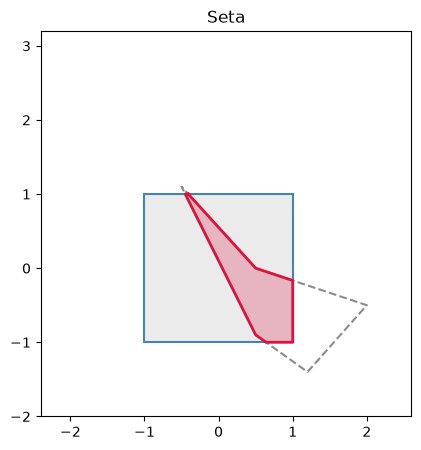

In [9]:
arrow = [(0.5,0.0),(2.0,-0.5),(1.2,-1.4),(0.5,-0.9),(-0.5,1.1)]
arrow_clip = sutherland_hodgman(arrow)
print(f"Seta — {len(arrow_clip)} vértices:")
for i,(x,y) in enumerate(arrow_clip,1): print(f"  ({x:+.4f}, {y:+.4f})")
plot_polygon("Seta", arrow, arrow_clip)
